<a href="https://colab.research.google.com/github/okonbright657-hue/GET-324-MINI-PROJECT-GROUP-5/blob/main/notebook/fresh_vs_rotten_apple_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q kaggle

In [5]:
import kagglehub

path = kagglehub.dataset_download("srishtisharma9977/fresh-apple-vs-rotten-apple-classification")

print(path)

/root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2


In [6]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Directories:", dirs)
    print("Files:", files[:5])  # Show first 5 files
    print("-" * 50)

/root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2
Directories: ['Apple vs Rotten Classification']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2/Apple vs Rotten Classification
Directories: ['train', 'validation', 'test']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2/Apple vs Rotten Classification/train
Directories: ['Fresh', 'Rotten']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2/Apple vs Rotten Classification/train/Fresh
Directories: []
Files: ['rotated_by_45_Screen Shot 2018-06-08 at 5.27.49 PM.png', 'rotated_by_15_Screen Shot 2018-06-08 at 5.21.06 PM.png', 'vertical_flip_Screen Sh

In [7]:
import os

dataset_path = os.path.join(path, "Apple vs Rotten Classification")

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "validation")
test_dir = os.path.join(dataset_path, "test")

In [8]:
import os
import re

def base_name(fname):
    return re.sub(r'^(rotated_by_\d+_|translation_|vertical_flip_|horizontal_flip_|saltandpepper_)', '', fname)

def get_base_names(folder):
    names = set()
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            names.add(base_name(f))
    return names

train_bases = get_base_names(train_dir)
val_bases   = get_base_names(val_dir)
test_bases  = get_base_names(test_dir)

print("Train ∩ Val overlap:", len(train_bases & val_bases))
print("Train ∩ Test overlap:", len(train_bases & test_bases))
print("Val ∩ Test overlap:", len(val_bases & test_bases))
print("Total unique base images:", len(train_bases | val_bases | test_bases))

Train ∩ Val overlap: 114
Train ∩ Test overlap: 467
Val ∩ Test overlap: 92
Total unique base images: 559


In [9]:
# STEP: Imports + reproducibility

import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')

results_dir = "results/apple_lab/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs('models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}' if gpus else 'No GPU — training on CPU (slower).')

TensorFlow version: 2.20.0
GPUs available: 1


In [10]:
# STEP2: Hyperparameters

IMAGE_HEIGHT = 128
IMAGE_WIDTH  = 128
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

In [11]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
    label_mode='binary',
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

class_names = train_dataset.class_names   #['Fresh', 'Rotten']
num_classes = len(class_names)
print(f'Classes: {class_names}')

Found 4024 files belonging to 2 classes.
Found 127 files belonging to 2 classes.
Found 880 files belonging to 2 classes.
Classes: ['Fresh', 'Rotten']


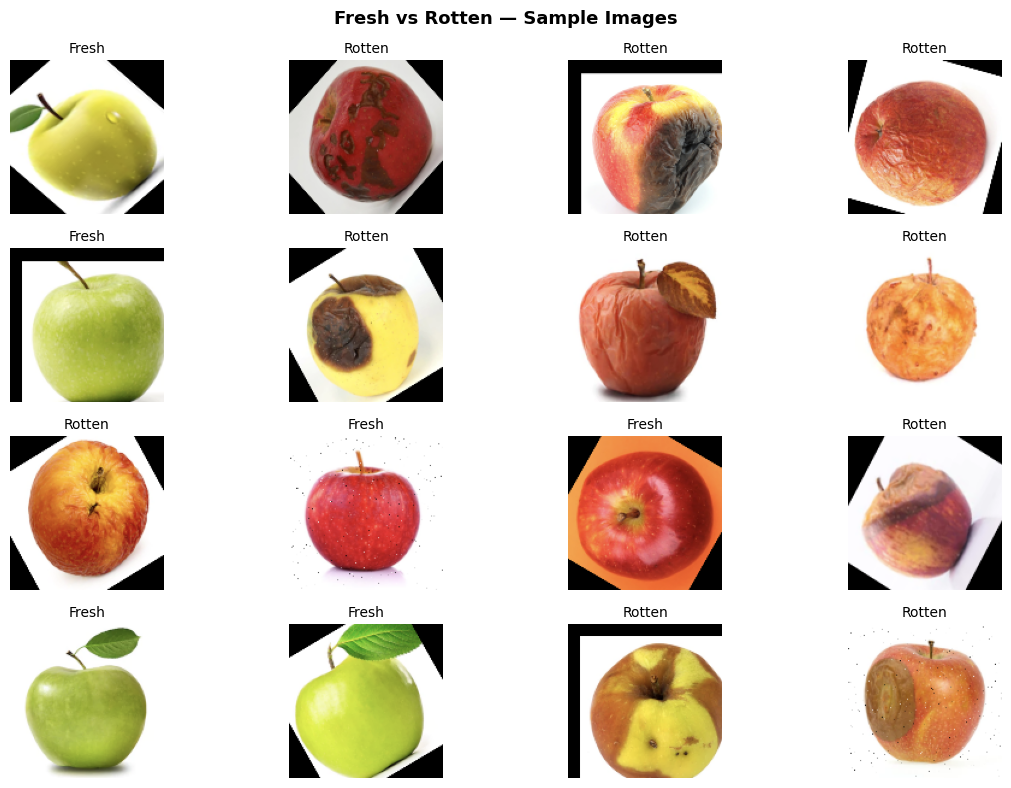

In [12]:
# STEP 3: Sanity-check a batch visually — catches wrong labels / corrupted files before you waste an hour training
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.suptitle('Fresh vs Rotten — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# STEP 4: Pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [14]:
# STEP 5: Augmentation
# augment dataset to contain rotated_by_X / translation / flip / saltandpepper copies
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

In [15]:
# STEP 6: Callbacks
def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Binary evaluation — single sigmoid output, threshold at 0.5."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return accuracy_score(y_true, y_pred)

In [16]:
# STEP: Custom CNN — binary output, single sigmoid unit

def build_custom_cnn(input_shape, augmentation):
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)   # single unit — binary

    return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,081 (1.23 MB)

 Trainable params: 321,185 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
# STEP: Compile + train
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1,
)

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.8718 - loss: 0.2954 - val_accuracy: 0.5827 - val_loss: 1.8242 - learning_rate: 0.0010
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9083 - loss: 0.2275 - val_accuracy: 0.8504 - val_loss: 0.3561 - learning_rate: 0.0010
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9247 - loss: 0.1891 - val_accuracy: 0.7402 - val_loss: 0.5646 - learning_rate: 0.0010
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9322 - loss: 0.1633 - val_accuracy: 0.7402 - val_loss: 0.5874 - learning_rate: 0.0010
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.9389 - loss: 0.1566 - val_accuracy: 0.8976 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.9389 - loss: 0.1527 - val_accuracy: 0.7559 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9500

Custom CNN -> val_loss: 0.0111, val_accuracy: 1.0000


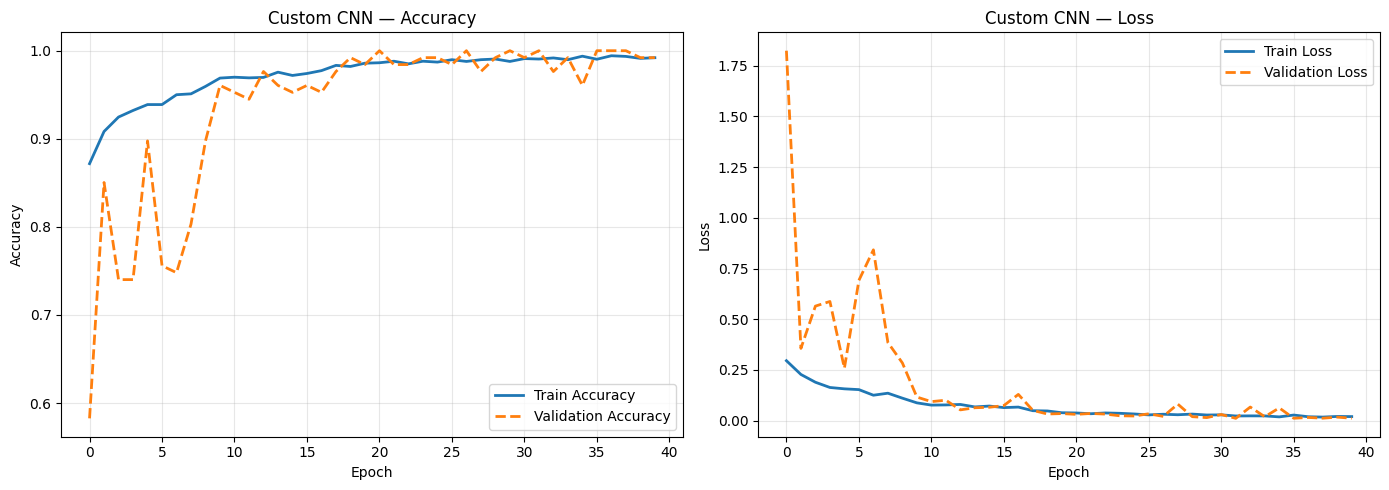


Custom CNN
Accuracy : 0.9989
Precision: 0.9981
Recall   : 1.0000
F1-Score : 0.9990

Classification Report:
              precision    recall  f1-score   support

       Fresh     1.0000    0.9973    0.9986       365
      Rotten     0.9981    1.0000    0.9990       515

    accuracy                         0.9989       880
   macro avg     0.9990    0.9986    0.9988       880
weighted avg     0.9989    0.9989    0.9989       880



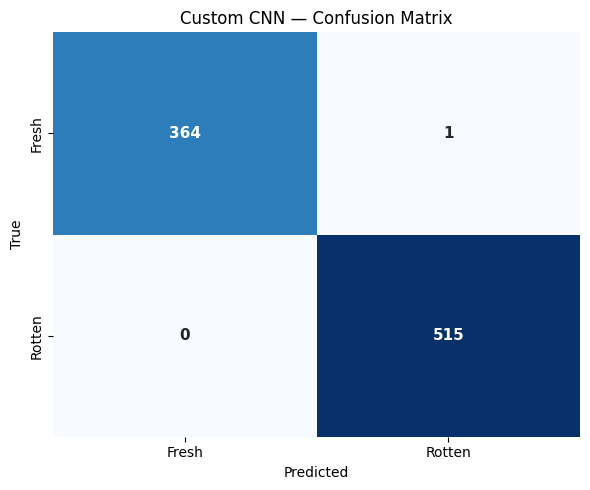

In [18]:
# STEP: Evaluate
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}, val_accuracy: {cnn_val_acc:.4f}')

plot_learning_curves(cnn_history, 'Custom CNN')
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')